In [1]:
import sys; sys.path.insert(0, "..")
import glob
import numpy as np
import matplotlib.pyplot as plt
import src.analysis as an

TAUS = [4, 6, 9, 13, 20]

def all_final(tau):
    return np.concatenate([np.load(f)["phi_final"]
                           for f in sorted(glob.glob(f"../data/2D_tau{tau}/chunk_*.npz"))])

tau=  4  wall=3977.0  xi=  4.1  domains/side=31.1  n=150
tau=  6  wall=3252.2  xi=  5.0  domains/side=25.4  n=100
tau=  9  wall=2318.1  xi=  7.1  domains/side=18.1  n=150
tau= 13  wall=1290.5  xi= 12.7  domains/side=10.1  n=150
tau= 20  wall= 519.5  xi= 31.5  domains/side= 4.1  n=150

wall ~ tau^(-1.252 ± 0.202)


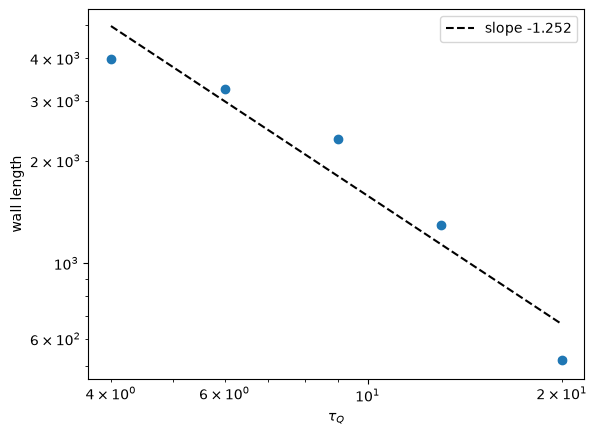

In [3]:
mean, err = [], []
for tau in TAUS:
    w = an.wall_length(all_final(tau))
    mean.append(w.mean()); err.append(w.std()/np.sqrt(len(w)))
    xi = 128**2 / w.mean()
    print(f"tau={tau:3d}  wall={w.mean():6.1f}  xi={xi:5.1f}  "
          f"domains/side={128/xi:4.1f}  n={len(w)}")

mean = np.array(mean)
p, cov = np.polyfit(np.log(TAUS), np.log(mean), 1, cov=True)
print(f"\nwall ~ tau^({p[0]:.3f} ± {np.sqrt(cov[0,0]):.3f})")

plt.errorbar(TAUS, mean, yerr=err, fmt="o", capsize=3)
plt.plot(TAUS, np.exp(np.polyval(p, np.log(TAUS))), "k--",
         label=f"slope {p[0]:.3f}")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("$\\tau_Q$"); plt.ylabel("wall length"); plt.legend()
plt.show()

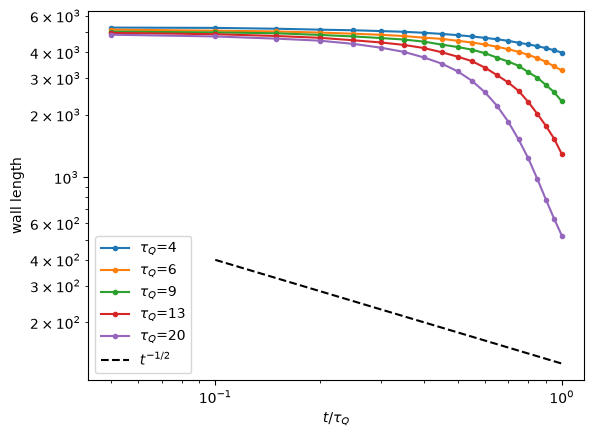

In [4]:
for tau in TAUS:
    d = np.load(sorted(glob.glob(f"../data/2D_tau{tau}/chunk_*.npz"))[0])
    t = d["snap_times"]
    wl = np.array([an.wall_length(d["snaps"][:, i]).mean() for i in range(len(t))])
    m = t > 0
    plt.loglog(t[m]/tau, wl[m], "o-", ms=3, label=f"$\\tau_Q$={tau}")

plt.loglog([0.1, 1], [400, 400*(10)**-0.5], "k--", label="$t^{-1/2}$")
plt.xlabel("$t/\\tau_Q$"); plt.ylabel("wall length"); plt.legend()
plt.show()

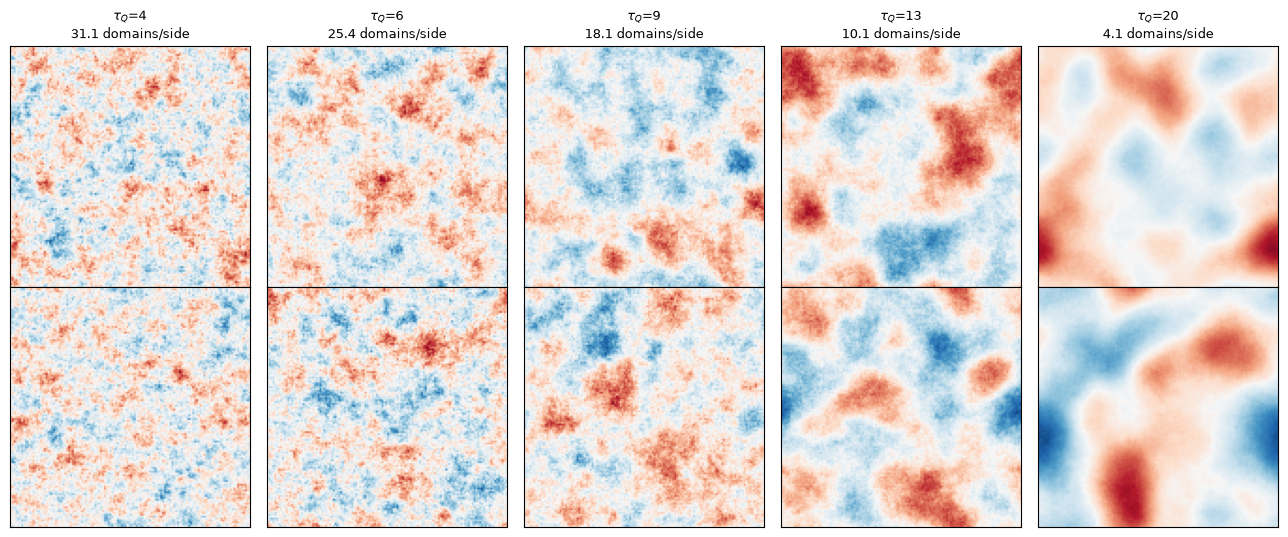

In [5]:
fig, axes = plt.subplots(2, len(TAUS), figsize=(2.6*len(TAUS), 5.4), squeeze=False)
for col, tau in enumerate(TAUS):
    f = all_final(tau)
    xi = 128**2 / an.wall_length(f).mean()
    for row in range(2):
        v = 1.1*np.abs(f[row]).max()
        axes[row, col].imshow(f[row], cmap="RdBu_r", vmin=-v, vmax=v)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[0, col].set_title(f"$\\tau_Q$={tau}\n{128/xi:.1f} domains/side", fontsize=9)
plt.tight_layout(); plt.show()

In [9]:
def correlation_length_v2(field, dx=1.0):
    """First zero crossing of the radially averaged correlation function
    of sign(field). Returns one value per sample, in sites (dx=1) or
    physical units (pass your dx)."""
    s = np.where(np.asarray(field) > 0, 1.0, -1.0)
    s = s - s.mean(axis=(-2, -1), keepdims=True)      # remove net magnetization
    n = s.shape[-1]

    f = np.fft.rfft2(s, axes=(-2, -1))
    c = np.fft.irfft2(np.abs(f)**2, s=(n, n), axes=(-2, -1)) / (n*n)

    # radial bins, using minimum-image distance
    ax = np.fft.fftfreq(n) * n
    yy, xx = np.meshgrid(ax, ax, indexing="ij")
    rr = np.sqrt(xx**2 + yy**2)
    rbin = np.round(rr).astype(int)
    nb = n//2
    counts = np.bincount(rbin.ravel(), minlength=nb+1)[:nb]

    out = np.empty(len(s))
    for i in range(len(s)):
        prof = np.bincount(rbin.ravel(), weights=c[i].ravel(),
                           minlength=nb+1)[:nb] / counts
        prof /= prof[0]
        below = np.where(prof < 0)[0]
        if len(below) == 0:
            out[i] = np.nan                            # never decorrelates
            continue
        j = below[0]
        # linear interpolation to the crossing
        out[i] = (j - 1 + prof[j-1]/(prof[j-1] - prof[j])) * dx
    return out


def xi_from_walls(field, dx=1.0):
    """Domain size from wall density, with the lattice-to-Euclidean
    correction (4/pi) applied. Still a proxy, but a calibrated one."""
    b  = np.asarray(field) > 0
    bx = (b != np.roll(b, -1, axis=-1)).sum(axis=(-1, -2))
    by = (b != np.roll(b, -1, axis=-2)).sum(axis=(-1, -2))
    L_lattice = (bx + by) * dx
    L_true    = L_lattice * (np.pi/4)                  # staircase correction
    area      = (b.shape[-1]*dx) * (b.shape[-2]*dx)
    return area / L_true


def xi_second_moment(field, dx=1.0):
    """Second-moment (Ornstein-Zernike) length from the structure factor:
    xi = sqrt( sum S(k)/k^2 / sum S(k) ), excluding k=0."""
    s = np.where(np.asarray(field) > 0, 1.0, -1.0)
    s = s - s.mean(axis=(-2, -1), keepdims=True)
    n = s.shape[-1]
    S = np.abs(np.fft.fft2(s, axes=(-2, -1)))**2

    k = 2*np.pi*np.fft.fftfreq(n, d=dx)
    ky, kx = np.meshgrid(k, k, indexing="ij")
    k2 = kx**2 + ky**2
    k2[0, 0] = np.inf                                  # drop the k=0 mode

    num = (S / k2).sum(axis=(-2, -1))
    den = S.sum(axis=(-2, -1))
    return np.sqrt(num/den)

In [12]:
import numpy as np


def xi(field, dx=1.0, method="corr", target=np.exp(-1.0)):
    """Correlation length of the domain pattern in sign(field).

    Measured from the radially averaged two-point correlation function
    C(r) of the sign field, with the net magnetization removed:

        C(r) = <s(0) s(r)> - <s>^2,   normalized so C(0) = 1

    xi is the distance at which C(r) first falls to `target` (default 1/e).
    Using 1/e rather than the zero crossing avoids the saturation problem:
    C(r) can stay positive out to the box size when a sample has few
    domains, but it always decays through 1/e first.

    method="corr"  -> 1/e decay length of C(r)     (recommended)
    method="fit"   -> exponential fit to C(r) over the decaying region

    Returns one value per sample, in units of dx.
    Acts on the last two axes; works on a stack of snapshots.
    """
    s = np.where(np.asarray(field) > 0, 1.0, -1.0)
    s = s.reshape(-1, *s.shape[-2:])
    n = s.shape[-1]

    # subtract per-sample mean so C(r) -> 0 at large r
    s = s - s.mean(axis=(-2, -1), keepdims=True)

    # C(r) via Wiener-Khinchin (periodic box, so this is exact)
    f = np.fft.fft2(s, axes=(-2, -1))
    c = np.fft.ifft2(np.abs(f) ** 2, axes=(-2, -1)).real / (n * n)

    # radial average using minimum-image distances
    ax = np.fft.fftfreq(n) * n
    yy, xx = np.meshgrid(ax, ax, indexing="ij")
    rbin = np.round(np.sqrt(xx**2 + yy**2)).astype(int)
    nb = n // 2
    counts = np.bincount(rbin.ravel(), minlength=nb + 1)[:nb]

    out = np.empty(len(s))
    for i in range(len(s)):
        prof = np.bincount(rbin.ravel(), weights=c[i].ravel(),
                           minlength=nb + 1)[:nb] / counts
        prof = prof / prof[0]

        if method == "fit":
            # fit log C(r) over the range where C is between 0.8 and 0.1
            m = (prof < 0.8) & (prof > 0.1)
            if m.sum() < 3:
                out[i] = np.nan
                continue
            r = np.arange(nb)[m]
            slope = np.polyfit(r, np.log(prof[m]), 1)[0]
            out[i] = -1.0 / slope * dx
            continue

        below = np.where(prof < target)[0]
        if len(below) == 0 or below[0] == 0:
            out[i] = np.nan          # never decays: box too small for this sample
            continue
        j = below[0]
        # linear interpolation between r = j-1 and r = j
        frac = (prof[j - 1] - target) / (prof[j - 1] - prof[j])
        out[i] = (j - 1 + frac) * dx

    return out

In [13]:
for tau in TAUS:
    f = np.load(sorted(glob.glob(f"../data/2D_tau{tau}/chunk_*.npz"))[0])["phi_final"]
    a = xi(f)
    print(f"tau={tau:3d}  xi = {np.nanmean(a):5.2f} ± {np.nanstd(a):4.2f}   "
          f"nan: {np.isnan(a).sum()}/{len(a)}")

tau=  4  xi =  2.10 ± 0.32   nan: 0/50
tau=  6  xi =  3.87 ± 0.53   nan: 0/50
tau=  9  xi =  7.03 ± 0.85   nan: 0/50
tau= 13  xi = 10.49 ± 1.46   nan: 0/50
tau= 20  xi = 14.37 ± 2.14   nan: 0/50


In [15]:
xi_vals = np.array([2.10, 3.87, 7.03, 10.49, 14.37])
p, cov = np.polyfit(np.log(TAUS), np.log(xi_vals), 1, cov=True)
print(f"xi ~ tau^({p[0]:.3f} ± {np.sqrt(cov[0,0]):.3f})")

for lo in range(5):
    q = np.polyfit(np.log(TAUS[lo:]), np.log(xi_vals[lo:]), 1)
    print(f"  tau >= {TAUS[lo]}: {q[0]:+.3f}")

xi ~ tau^(1.212 ± 0.101)
  tau >= 4: +1.212
  tau >= 6: +1.087
  tau >= 9: +0.891
  tau >= 13: +0.731
  tau >= 20: +0.445


/tmp/ipykernel_16970/2212329394.py:6: RankWarning: Polyfit may be poorly conditioned
  q = np.polyfit(np.log(TAUS[lo:]), np.log(xi_vals[lo:]), 1)


In [1]:
import sys; sys.path.insert(0, "..")
import glob, os
import numpy as np
import matplotlib.pyplot as plt

def xi(field, dx=1.0, target=np.exp(-1.0)):
    s = np.where(np.asarray(field) > 0, 1.0, -1.0)
    s = s.reshape(-1, *s.shape[-2:])
    n = s.shape[-1]
    s = s - s.mean(axis=(-2, -1), keepdims=True)
    f = np.fft.fft2(s, axes=(-2, -1))
    c = np.fft.ifft2(np.abs(f)**2, axes=(-2, -1)).real / (n*n)
    ax = np.fft.fftfreq(n) * n
    yy, xx = np.meshgrid(ax, ax, indexing="ij")
    rbin = np.round(np.sqrt(xx**2 + yy**2)).astype(int)
    nb = n // 2
    counts = np.bincount(rbin.ravel(), minlength=nb+1)[:nb]
    out = np.empty(len(s))
    for i in range(len(s)):
        prof = np.bincount(rbin.ravel(), weights=c[i].ravel(), minlength=nb+1)[:nb] / counts
        prof = prof / prof[0]
        below = np.where(prof < target)[0]
        if len(below) == 0 or below[0] == 0:
            out[i] = np.nan; continue
        j = below[0]
        out[i] = (j - 1 + (prof[j-1]-target)/(prof[j-1]-prof[j])) * dx
    return out

files = sorted(glob.glob("../data/xi_scan_N256/*.npz"),
               key=lambda f: float(os.path.basename(f)[3:-4]))
data  = {float(os.path.basename(f)[3:-4]): np.load(f) for f in files}
TAUS  = sorted(data)
print("taus:", TAUS)

taus: [10.0, 20.0, 40.0, 80.0, 160.0]


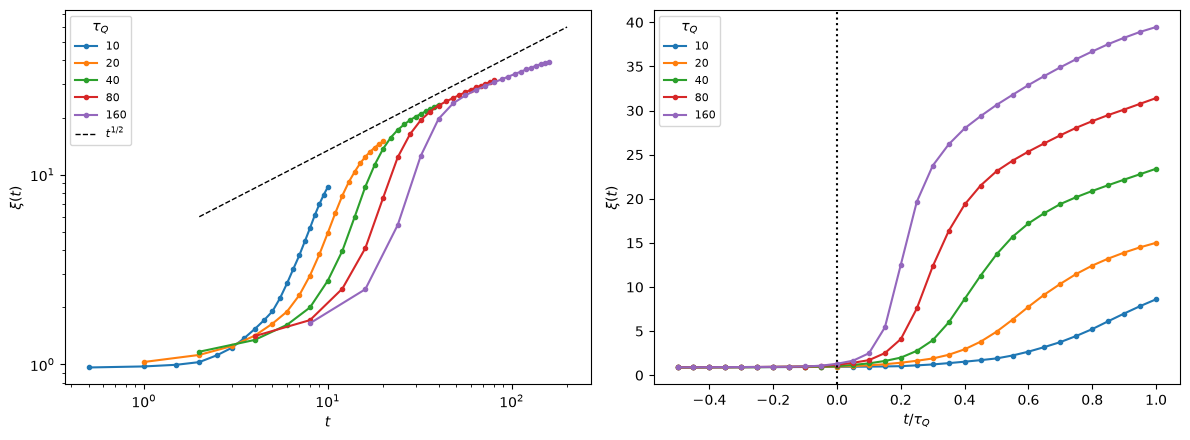

In [2]:
xi_t = {}
for tau in TAUS:
    d = data[tau]
    xi_t[tau] = np.array([np.nanmean(xi(d["snaps"][:, i]))
                          for i in range(len(d["snap_times"]))])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for tau in TAUS:
    t = data[tau]["snap_times"]; m = t > 0
    ax[0].loglog(t[m], xi_t[tau][m], "o-", ms=3, label=f"{tau:g}")
    ax[1].plot(t/tau, xi_t[tau], "o-", ms=3, label=f"{tau:g}")

tt = np.array([2, 200])
ax[0].loglog(tt, 6*(tt/tt[0])**0.5, "k--", lw=1, label="$t^{1/2}$")
ax[0].set_xlabel("$t$"); ax[0].set_ylabel("$\\xi(t)$")
ax[1].set_xlabel("$t/\\tau_Q$"); ax[1].set_ylabel("$\\xi(t)$")
ax[1].axvline(0, color="k", ls=":")
for a in ax: a.legend(title="$\\tau_Q$", fontsize=8)
plt.tight_layout(); plt.show()

In [3]:
fracs = [0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
print(f"{'t/tau':>7} {'exponent':>10}")
for fr in fracs:
    vals = []
    for tau in TAUS:
        t = data[tau]["snap_times"]
        i = int(np.argmin(np.abs(t/tau - fr)))
        vals.append(xi_t[tau][i])
    p = np.polyfit(np.log(TAUS), np.log(vals), 1)[0]
    print(f"{fr:7.2f} {p:10.3f}")
print("\nKZ predicts nu/(1+z nu); Allen-Cahn coarsening gives 0.5")

  t/tau   exponent
   0.05      0.200
   0.10      0.331
   0.20      0.875
   0.30      1.126
   0.50      1.024
   0.75      0.731
   1.00      0.546

KZ predicts nu/(1+z nu); Allen-Cahn coarsening gives 0.5


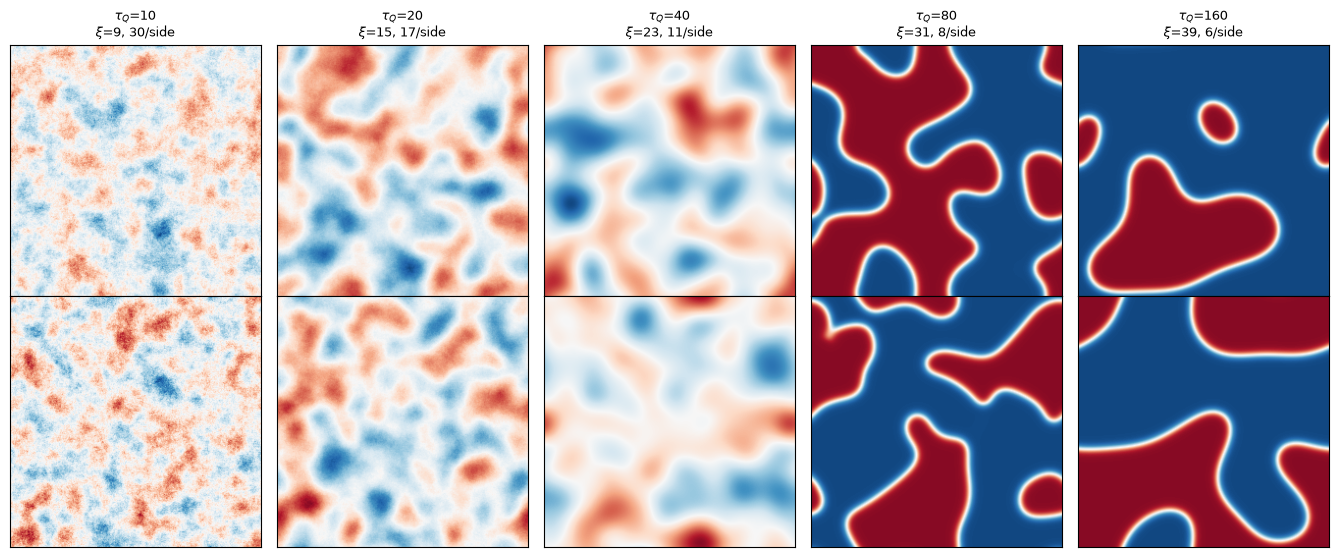

In [4]:
fig, axes = plt.subplots(2, len(TAUS), figsize=(2.7*len(TAUS), 5.6), squeeze=False)
for col, tau in enumerate(TAUS):
    f = data[tau]["phi_final"]
    x = np.nanmean(xi(f))
    for row in range(2):
        v = 1.1*np.abs(f[row]).max()
        axes[row, col].imshow(f[row], cmap="RdBu_r", vmin=-v, vmax=v)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[0, col].set_title(f"$\\tau_Q$={tau:g}\n$\\xi$={x:.0f}, {256/x:.0f}/side", fontsize=9)
plt.tight_layout(); plt.show()

In [5]:
for tau in TAUS:
    t = data[tau]["snap_times"]
    for fr in [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]:
        i = int(np.argmin(np.abs(t/tau - fr)))
        print(f"tau={tau:5g}  t/tau={fr:4.2f}  xi={xi_t[tau][i]:6.2f}")
    print()

tau=   10  t/tau=0.05  xi=  0.96
tau=   10  t/tau=0.10  xi=  0.98
tau=   10  t/tau=0.20  xi=  1.03
tau=   10  t/tau=0.30  xi=  1.22
tau=   10  t/tau=0.50  xi=  1.90
tau=   10  t/tau=1.00  xi=  8.61

tau=   20  t/tau=0.05  xi=  1.03
tau=   20  t/tau=0.10  xi=  1.12
tau=   20  t/tau=0.20  xi=  1.42
tau=   20  t/tau=0.30  xi=  1.90
tau=   20  t/tau=0.50  xi=  4.93
tau=   20  t/tau=1.00  xi= 15.01

tau=   40  t/tau=0.05  xi=  1.17
tau=   40  t/tau=0.10  xi=  1.35
tau=   40  t/tau=0.20  xi=  2.00
tau=   40  t/tau=0.30  xi=  3.97
tau=   40  t/tau=0.50  xi= 13.71
tau=   40  t/tau=1.00  xi= 23.40

tau=   80  t/tau=0.05  xi=  1.41
tau=   80  t/tau=0.10  xi=  1.71
tau=   80  t/tau=0.20  xi=  4.10
tau=   80  t/tau=0.30  xi= 12.35
tau=   80  t/tau=0.50  xi= 23.13
tau=   80  t/tau=1.00  xi= 31.41

tau=  160  t/tau=0.05  xi=  1.65
tau=  160  t/tau=0.10  xi=  2.49
tau=  160  t/tau=0.20  xi= 12.54
tau=  160  t/tau=0.30  xi= 23.76
tau=  160  t/tau=0.50  xi= 30.64
tau=  160  t/tau=1.00  xi= 39.47



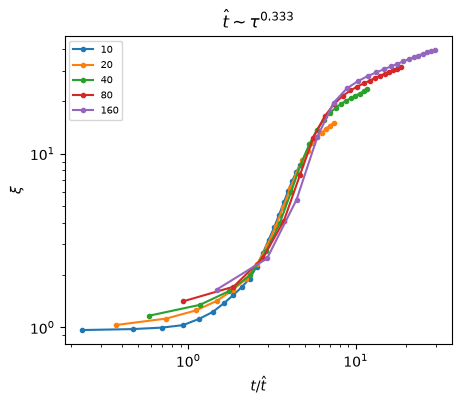

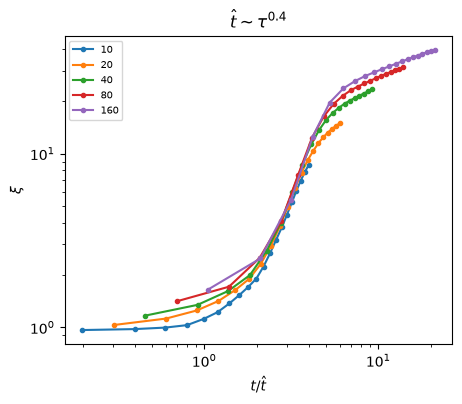

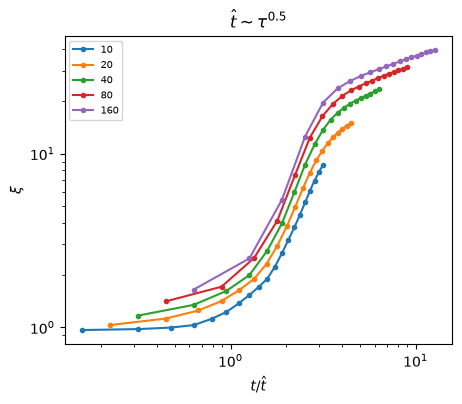

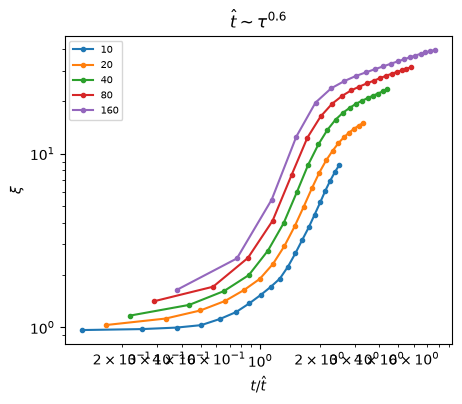

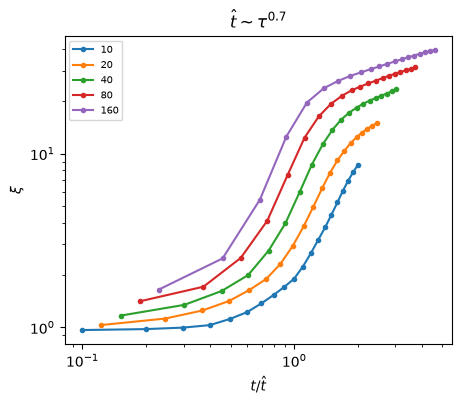

In [7]:
for alpha in [0.333, 0.4, 0.5, 0.6, 0.7]:
    plt.figure(figsize=(5,4))
    for tau in TAUS:
        t = data[tau]["snap_times"]
        that = tau**alpha
        m = t > 0
        plt.loglog(t[m]/that, xi_t[tau][m], "o-", ms=3, label=f"{tau:g}")
    plt.title(f"$\\hat t \\sim \\tau^{{{alpha}}}$")
    plt.xlabel("$t/\\hat t$"); plt.ylabel("$\\xi$"); plt.legend(fontsize=7)
    plt.show()

In [8]:
alpha = 0.33
for ratio in [1, 2, 3, 5]:            # t/that values inside the collapse
    vals = []
    for tau in TAUS:
        t = data[tau]["snap_times"]
        i = int(np.argmin(np.abs(t - ratio * tau**alpha)))
        vals.append(xi_t[tau][i])
    p = np.polyfit(np.log(TAUS), np.log(vals), 1)[0]
    print(f"t/that = {ratio}:  xi ~ tau^{p:.3f}")

t/that = 1:  xi ~ tau^0.154
t/that = 2:  xi ~ tau^-0.004
t/that = 3:  xi ~ tau^-0.095
t/that = 5:  xi ~ tau^-0.160


In [9]:
def xi_first_moment(field, dx=1.0):
    """L = 2*pi / <k>, with <k> the first moment of the spherically
    averaged structure factor of sign(field). Standard coarsening
    definition. One value per sample."""
    s = np.where(np.asarray(field) > 0, 1.0, -1.0)
    s = s.reshape(-1, *s.shape[-2:])
    n = s.shape[-1]
    s = s - s.mean(axis=(-2, -1), keepdims=True)

    S = np.abs(np.fft.fft2(s, axes=(-2, -1)))**2 / (n*n)

    kx = 2*np.pi*np.fft.fftfreq(n, d=dx)
    KY, KX = np.meshgrid(kx, kx, indexing="ij")
    k = np.sqrt(KX**2 + KY**2)

    m = k > 0                                  # drop the k=0 mode
    kmean = (k[m]*S[:, m]).sum(-1) / S[:, m].sum(-1)
    return 2*np.pi / kmean

In [10]:
def xi_first_moment(field, dx=1.0):
    s = np.where(np.asarray(field) > 0, 1.0, -1.0)
    s = s.reshape(-1, *s.shape[-2:])
    n = s.shape[-1]
    s = s - s.mean(axis=(-2, -1), keepdims=True)
    S = np.abs(np.fft.fft2(s, axes=(-2, -1)))**2 / (n*n)
    kx = 2*np.pi*np.fft.fftfreq(n, d=dx)
    KY, KX = np.meshgrid(kx, kx, indexing="ij")
    k = np.sqrt(KX**2 + KY**2)
    m = k > 0
    kmean = (k[m]*S[:, m]).sum(-1) / S[:, m].sum(-1)
    return 2*np.pi / kmean

for tau in TAUS:
    f = data[tau]["phi_final"]
    print(f"tau={tau:5g}  L={xi_first_moment(f).mean():6.2f}  "
          f"(old 1/e: {np.nanmean(xi(f)):5.2f})")

tau=   10  L=  8.75  (old 1/e:  8.61)
tau=   20  L= 22.28  (old 1/e: 15.01)
tau=   40  L= 36.84  (old 1/e: 23.40)
tau=   80  L= 47.95  (old 1/e: 31.41)
tau=  160  L= 59.32  (old 1/e: 39.47)


In [11]:
L_t = {}
for tau in TAUS:
    d = data[tau]
    L_t[tau] = np.array([xi_first_moment(d["snaps"][:, i]).mean()
                         for i in range(len(d["snap_times"]))])

for tau in TAUS:
    t = data[tau]["snap_times"]
    for fr in [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]:
        i = int(np.argmin(np.abs(t/tau - fr)))
        print(f"tau={tau:5g}  t/tau={fr:4.2f}  L={L_t[tau][i]:6.2f}")
    print()

tau=   10  t/tau=0.05  L=  3.88
tau=   10  t/tau=0.10  L=  3.93
tau=   10  t/tau=0.20  L=  4.03
tau=   10  t/tau=0.30  L=  4.16
tau=   10  t/tau=0.50  L=  4.61
tau=   10  t/tau=1.00  L=  8.75

tau=   20  t/tau=0.05  L=  4.02
tau=   20  t/tau=0.10  L=  4.09
tau=   20  t/tau=0.20  L=  4.28
tau=   20  t/tau=0.30  L=  4.59
tau=   20  t/tau=0.50  L=  5.84
tau=   20  t/tau=1.00  L= 22.28

tau=   40  t/tau=0.05  L=  4.13
tau=   40  t/tau=0.10  L=  4.24
tau=   40  t/tau=0.20  L=  4.64
tau=   40  t/tau=0.30  L=  5.40
tau=   40  t/tau=0.50  L= 10.66
tau=   40  t/tau=1.00  L= 36.84

tau=   80  t/tau=0.05  L=  4.28
tau=   80  t/tau=0.10  L=  4.48
tau=   80  t/tau=0.20  L=  5.39
tau=   80  t/tau=0.30  L=  8.22
tau=   80  t/tau=0.50  L= 31.95
tau=   80  t/tau=1.00  L= 47.95

tau=  160  t/tau=0.05  L=  4.44
tau=  160  t/tau=0.10  L=  4.83
tau=  160  t/tau=0.20  L=  7.67
tau=  160  t/tau=0.30  L= 22.86
tau=  160  t/tau=0.50  L= 46.94
tau=  160  t/tau=1.00  L= 59.32



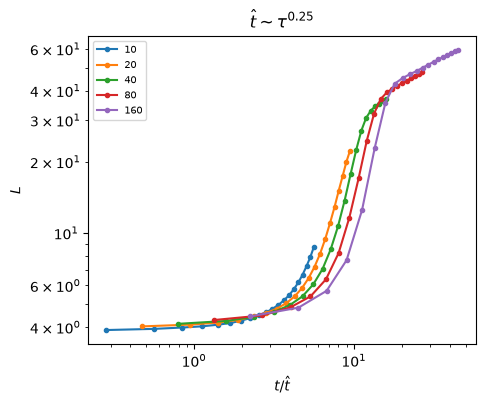

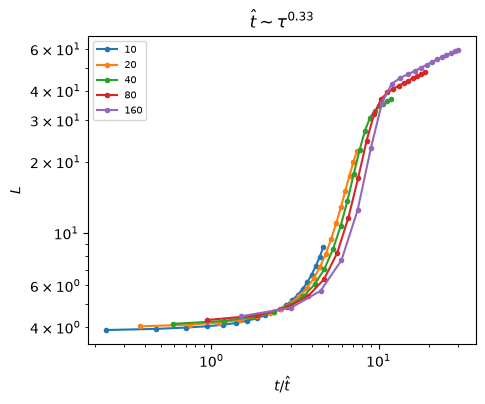

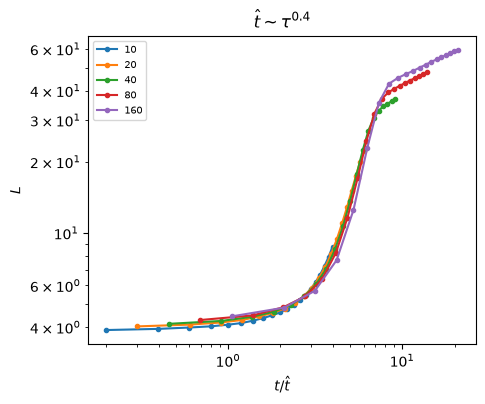

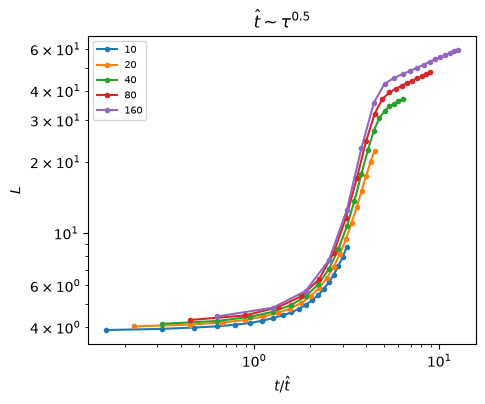

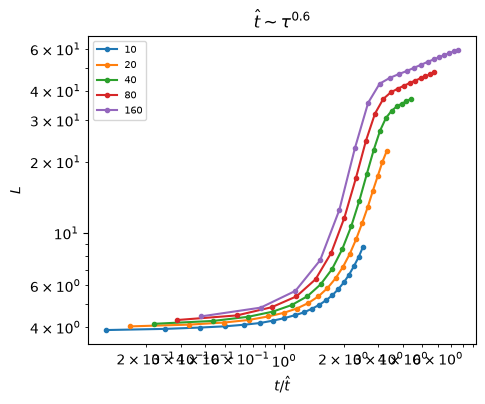

In [12]:
for alpha in [0.25, 0.33, 0.4, 0.5, 0.6]:
    plt.figure(figsize=(5, 4))
    for tau in TAUS:
        t = data[tau]["snap_times"]; m = t > 0
        plt.loglog(t[m]/tau**alpha, L_t[tau][m], "o-", ms=3, label=f"{tau:g}")
    plt.title(f"$\\hat t \\sim \\tau^{{{alpha}}}$")
    plt.xlabel("$t/\\hat t$"); plt.ylabel("$L$"); plt.legend(fontsize=7)
    plt.show()

In [14]:
L = np.array([22.28, 36.84, 47.95, 59.32])
T = np.array([20, 40, 80, 160])
p, cov = np.polyfit(np.log(T), np.log(L), 1, cov=True)
print(f"L ~ tau^({p[0]:.3f} ± {np.sqrt(cov[0,0]):.3f})")
for lo in range(2):
    print(f"  tau >= {T[lo]}: {np.polyfit(np.log(T[lo:]), np.log(L[lo:]), 1)[0]:+.3f}")

L ~ tau^(0.462 ± 0.069)
  tau >= 20: +0.462
  tau >= 40: +0.344
